<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/2026.06/Lab4_PE_keithley_90CV_anode_corr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.1 Automated measurements. Diodes

v0.2.2 Lamp + Filters

v0.3.0 Du Bridges method extracting V0

v0.3.1 Resume added

v0.3.2 90CV tube

v0.4.0 anode+dark current as baseline, not dark current as it was before

# Resume

## Method

We measured photoelectric current using an [90CV](https://frank.pocnet.net/sheets/030/9/90CV.pdf) photocell with S1 curve sensetive to red spectrum.

Current–voltage (I–V) curves were recorded automatically using a
[Python script](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/photoelectric_v2.py).

As light sources we used violet 397, blue 456, green 525 and yellow 592 LEDs.

The violet LED spectra was observed on optical spectroscope with diffraction grating 500/mm. The spectra starts at 11.46 degrees (397nm) and has long tail of blue and greenish spectra less energy waves.

The Red LED on optical spectroscope diffracts to a red color band of 10-12 degrees. I took the smallest visible angle for calculating wavelength.

I took retarding voltage current $ V_{cell} \le -1.5\textrm{V}$ as a baseline current, including dark current and anode current. Then  calculated cathode current as difference $I_{cathode} = I_{raw} - \textrm{baseline}$.

The stopping voltage $V_0$ was extracted from each I–V curve using the
[Du Bridge method](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/jpsj.8.723.pdf):
plotting $\sqrt{I}$ versus $V$ and extrapolating the linear region to zero. here $I$ is cathode current defined above.
Measurements were repeated at several light intensities per wavelength.

## Results

the 90CV photocell is indeed too sensetive in red part of the spectrum.


In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request

In [2]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


# Dark and Anode current

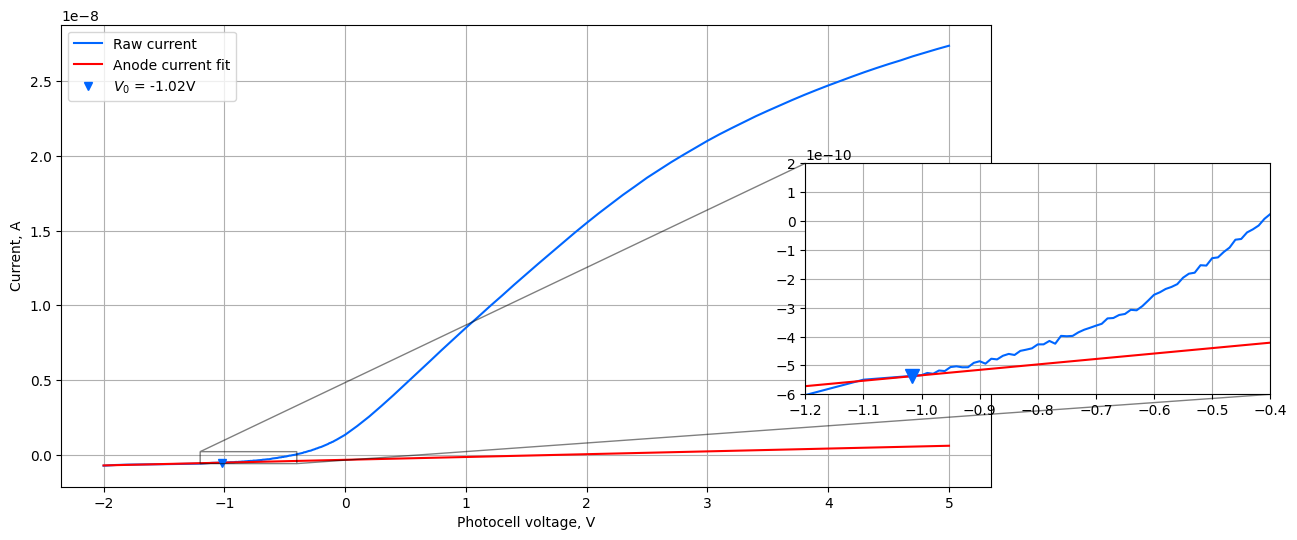

In [3]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.06/'

def find_root(V, I,
              anode_Vmax=-1.5,
              noise_k=5.0,
              window_frac=0.5,
              return_diagnostics=False):
    """
    Find the photoelectric stopping voltage V0 by the Du Bridge method
    with linear subtraction of the (anode + dark + leakage) baseline.

    Idea
    ----
    In the strong-retarding region the cathode current is zero, so the
    measured current there is the sum of everything non-cathodic:
    anode photoemission + dark current + leakage. We fit a straight line
    to that region and subtract it. Whatever is left is the cathode
    current; it sits on zero and *departs* from it at V0.
    Because the baseline is taken from the illuminated curve itself,
    the dark current is already included -- no separate dark subtraction.

    Near threshold  I_cathode  ~  (V - V0)^2  (Du Bridge), so sqrt(I)
    is linear in V and its extrapolation to zero gives V0.

    Parameters
    ----------
    V, I : arrays
        Voltage (V) and *measured* current (any unit). Do NOT pre-subtract
        dark current -- this routine removes it via the baseline.
    anode_Vmax : float
        Upper edge of the baseline-fit region; points with V <= anode_Vmax
        are assumed cathode-free. Make it more negative than the most
        negative expected V0. Extend your sweep so a flat region exists.
    noise_k : float
        A point counts as "cathode on" when the residual exceeds
        noise_k * (baseline scatter).
    window_frac : float
        Fraction of the sqrt-current range, measured from threshold,
        used for the linear Du Bridge fit (the near-threshold straight
        part). 0.5 = lower half.
    return_diagnostics : bool
        If True, also return a dict for plotting / sanity checks.

    Returns
    -------
    V0 : float   (negative; the stopping voltage). np.nan if not extractable.
    [diag] : dict (only if return_diagnostics=True)
    """
    V = np.asarray(V, float); I = np.asarray(I, float)
    order = np.argsort(V); V, I = V[order], I[order]

    # 1. baseline = anode + dark + leakage, fitted where cathode is off
    base = V <= anode_Vmax
    if base.sum() < 3:
        return (np.nan, {"reason": "no flat baseline region; extend sweep"}) \
            if return_diagnostics else np.nan
    lr = linregress(V[base], I[base])
    baseline = lr.slope * V + lr.intercept
    R = I - baseline                      # cathode current
    noise = np.std(R[base])

    # 2. cathode-on points in the retarding region
    on = (R > noise_k * noise) & (V < 0)
    if on.sum() < 5:
        return (np.nan, {"reason": "too few cathode points", "baseline": lr}) \
            if return_diagnostics else np.nan

    x = V[on]; y = np.sqrt(R[on])

    # 3. near-threshold linear segment (lower window_frac of sqrt range)
    ylo, yhi = y.min(), y.max()
    near = y <= ylo + window_frac * (yhi - ylo)
    if near.sum() < 3:
        near = np.argsort(y)[:max(3, int(0.4 * len(y)))]  # fallback
    db = linregress(x[near], y[near])
    V0 = -db.intercept / db.slope

    if return_diagnostics:
        return V0, {"baseline": lr, "noise": noise, "R": R, "V": V,
                    "cathode_mask": on, "fit_mask_in_on": near, "dubridge": db}
    return V0


def v0_sensitivity(V, I, fracs=(0.2, 0.3, 0.4, 0.5), **kw):
    """Spread of V0 over several window fractions = method systematic."""
    vals = [find_root(V, I, window_frac=f, **kw) for f in fracs]
    vals = [v for v in vals if np.isfinite(v)]
    if not vals:
        return np.nan, np.nan
    return float(np.mean(vals)), float(np.ptp(vals))  # mean, peak-to-peak

# example
fig, ax = plt.subplots(1, 1, figsize=(12,6))
name, wl = 'blue_diode_90CV_right_side', 456
color = wavelength_to_color(wl)
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
LED_V,V_set,V_actual,I_avg_A, I_std_A,  = np.genfromtxt(text, \
                              delimiter=',', usecols=[0,1,2,3,4], skip_header=1, unpack=True)
powers = np.unique(LED_V)
V = V_set[LED_V==powers[1]]
I = I_avg_A[LED_V==powers[1]]
V0, debug = find_root(V, I, anode_Vmax=-1.5, return_diagnostics=True)
anode_fit = debug['baseline']
plt.plot(V, I, color=color, label='Raw current')
plt.plot(V, anode_fit.slope * V + anode_fit.intercept, color='red', label='Anode current fit')
plt.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, label=rf'$V_0$ = {V0:.2f}V')
plt.xlabel('Photocell voltage, V')
plt.ylabel('Current, A')
plt.grid()
plt.legend()

axins = plt.gca().inset_axes([0.8, 0.2, 0.5, 0.5]) # [x, y, width, height] in axes coordinates
axins.plot(V, I, color=color)
axins.plot(V, anode_fit.slope * V + anode_fit.intercept, color='red')
axins.plot(V0, anode_fit.slope * V0 + anode_fit.intercept, 'v', color=color, ms=10)

axins.set_xlim(-1.2, -0.4)
axins.set_ylim(-6e-10,2e-10)
axins.grid(True)
ax.indicate_inset_zoom(axins, edgecolor="black")

<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3667/1838969676.py:74: SyntaxWarning: invalid escape sequence '\s'
  ax[2].set_ylabel('Du Bridge, $\sqrt{I}$')


# color wavelength power V0 V0_err opacity
0 525 12.0 0.803 0.013 0.10#
 0 525 14.0 0.780 0.021 0.28#
 0 525 18.0 0.863 0.008 0.63#
 0 525 20.0 0.888 0.025 0.81#
 0 525 22.0 0.980 0.049 0.99#
 1 456 8.0 0.925 0.046 0.10#
 1 456 10.0 1.039 0.051 0.40#
 1 456 12.0 1.128 0.055 0.69#
 1 456 14.0 1.244 0.089 0.99#
 2 650 1.8 0.534 0.026 0.10#
 2 650 1.9 0.562 0.014 0.99#
 3 397 2.9 1.461 0.112 0.10#
 3 397 3.0 1.510 0.125 0.28#
 3 397 3.3 1.515 0.113 0.81#
 3 397 3.4 1.515 0.114 0.99#
 4 397 2.9 1.455 0.085 0.10#
 4 397 3.0 1.546 0.089 0.55#
 4 397 3.1 1.608 0.088 0.99#
 


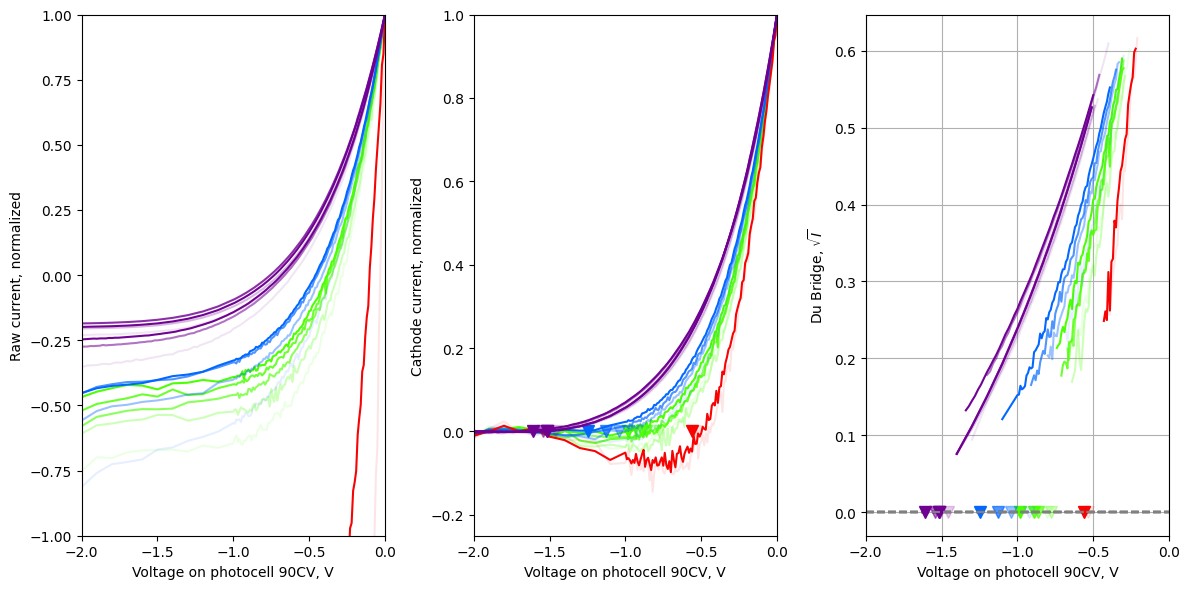

In [8]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.06/'
NORMPOINT = 0 #V
ANODE_VMAX = -1.5 #V
names = ['green_diode_90CV_right_side', 'blue_diode_90CV_right_side', 'red_diode_90CV_right_side', 'voilet_diode_90CV_11.46deg', '402']
waves = [525, 456, 650, 397, 397]
n = len(names)


fig, ax = plt.subplots(1, 3, figsize=(12,6), sharex=True)
plt.grid()

data = '# color wavelength power V0 V0_err opacity\n'


for i, name in enumerate(names):
  color= wavelength_to_color(waves[i])
  url = URL+ f'{name}.csv'
  text = request.urlopen(url).read().decode('utf-8').splitlines()
  LED_V,V_set,V_actual,I_avg_A, I_std_A,  = np.genfromtxt(text, \
                              delimiter=',', usecols=[0,1,2,3,4], skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power_index, power in enumerate(powers):


    V = V_set[LED_V==power]
    I = I_avg_A[LED_V==power]
    normalization_parameter = np.max(I[V <= NORMPOINT])
    I /= normalization_parameter
    opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))

    # Find points where current I crosses zero current line
    V0, d = find_root(V, I, anode_Vmax=ANODE_VMAX, return_diagnostics=True)
    # diagnostics
    R = d['R']
    on = d['cathode_mask']
    db = d['dubridge']

    # систематика от выбора окна (для погрешности в отчёте)
    v0_mean, v0_spread = v0_sensitivity(V, I, anode_Vmax=ANODE_VMAX)
    data += f'{i} {waves[i]} {power:.1f} {-v0_mean:.3f} {v0_spread:.3f} {opacity:.2f}#\n '

    # (1) сырая ВАХ + baseline

    ax[0].plot(V, I, '-', ms=1, color=color, alpha=opacity)
    #ax[0].plot(d['V'], baseline /, '--', color='#cc3333', label='baseline (анод+тёмный+утечки)')
    #ax[0].axvspan(d['V'].min(), ANODE_VMAX, color='#cc3333', alpha=.10)
    ax[0].set_xlim(-2, 0.);
    ax[0].set_ylim(-1, 1)
    ax[0].set_xlabel('Voltage on photocell 90CV, V');
    ax[0].set_ylabel('Raw current, normalized')
    ax[0].grid()

    # (2) остаток = катодный ток
    normalization_parameter = np.max(R[V <= NORMPOINT])
    R /= normalization_parameter
    db /= normalization_parameter
    ax[1].plot(d['V'], R, '-', ms=2, color=color, alpha=opacity)
    ax[1].plot(v0_mean, 0, 'v', ms=8, color=color, alpha=opacity)
    #ax[1].axvline(V0, color='#e08000', ls='--', label=f'V0 = {V0:.2f} В')
    ax[1].set_xlim(-2, 0.);
    ax[1].set_ylim(-0.25, 1)
    ax[1].set_xlabel('Voltage on photocell 90CV, V');
    ax[1].set_ylabel('Cathode current, normalized')
    ax[1].grid()

    # (3) Дю-Бридж: sqrt(R) vs V
    x = d['V'][on]; y = np.sqrt(R[on]); near = d['fit_mask_in_on']
    ax[2].axhline(0, color='gray', ls='--')
    ax[2].plot(v0_mean, 0, 'v', ms=8, color=color, alpha=opacity)
    ax[2].plot(x[near], y[near], '-', ms=2, color=color, alpha=opacity)
    ax[2].set_xlabel('Voltage on photocell 90CV, V');
    ax[2].set_ylabel('Du Bridge, $\sqrt{I}$')
    #ax[2].grid()
plt.tight_layout()

print(data)

# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_3667/3543102023.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / wl


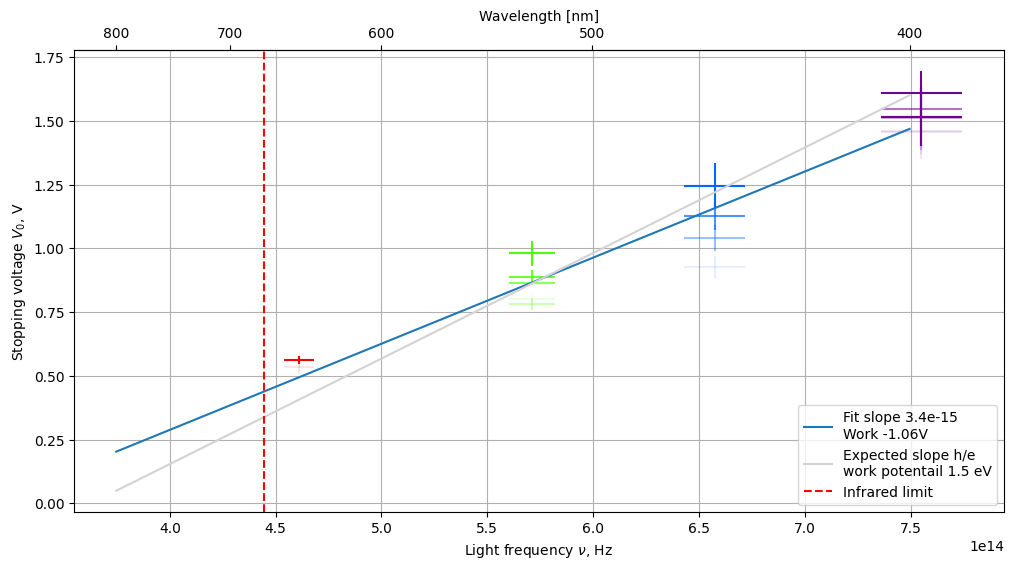

In [9]:
offset_expected = 1.5 # V, for Ag-O-Cs  Photocathode

def linear(nu, slope, offset):
    return slope * nu - offset

def wl2freq(wl):
    return c / wl


def freq2wl(nu):
    return c / nu * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(freq2wl, wl2freq))
secax.set_xlabel('Wavelength [nm]')


ix, wl, power, V0, V0_err, opacity = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
popt, pcov = curve_fit(linear, nu , V0)
slope = popt[0]
offset = popt[1]
err = np.sqrt(np.diag(pcov))
slope_err = err[0]
offset_err = err[1]



for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(nu[i], V0[i], yerr=V0_err[i], xerr=nu_err[i], ls='', color=wavelength_to_color(wl[i]*1e9), alpha=opacity[i])


wl_dense = np.linspace(400, 800)  * 1e-9
nu_dense = c / wl_dense

plt.plot(nu_dense, linear(nu_dense, slope, offset), label=f'Fit slope {slope:.1e}\nWork {-offset:.2f}V')
plt.plot(nu_dense, linear(nu_dense, h/e, offset_expected) , color='lightgray', label=f'Expected slope h/e\nwork potentail {offset_expected:.1f} eV')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light frequency $\nu$, Hz')
plt.ylabel(r'Stopping voltage $V_0$, V')
Infrared_PhotoEmission_limit = offset_expected / slope
plt.axvline(Infrared_PhotoEmission_limit, color='red', ls='--', label='Infrared limit')
plt.legend()
#plt.ylim(-0.25, 1.1)
plt.show()



# Обсуждение с языковой моделью CLAUDE OPUS
# Почему работа выхода «плавает» у фотоэлемента 90CV (катод S-1)

## Откуда берётся «единая работа выхода» в теории

В простой картине Эйнштейна металл имеет один уровень — энергию Ферми, выше которой состояний нет (при $T=0$). Все электроны сидят под общим «потолком», и чтобы вырвать самый верхний из них, нужна одна и та же энергия $\phi$ независимо от длины волны. Поэтому $V_0(\nu)$ — идеальная прямая с порогом-изломом на $\nu = \phi/h$, а работа выхода — единственное число.

## Почему у Ag-O-Cs это ломается

Катод S-1 — не металл, а сложная многослойная полупроводниковая структура: серебряная подложка, слой оксида серебра, в нём наночастицы (кластеры) металлического серебра, и поверх — цезий с цезиевым оксидом. Фотоэмиссия идёт сразу по нескольким каналам с **разными порогами**:

- **Валентная зона полупроводника** — самый высокий порог, требует синих и фиолетовых фотонов.
- **Примесные и донорные уровни** внутри запрещённой зоны, лежащие ближе к вакуумному уровню, — включаются на меньших энергиях, в зелёном и жёлтом.
- **Серебряные наночастицы** — дают плазмонный резонанс и собственную фотоэмиссию в красном и ИК, что и обеспечивает знаменитую чувствительность S-1 вплоть до 1100 нм.

Итог: у S-1 не один порог, а целый набор состояний, размазанный по энергии. Каждый из них — свой «потолок», с которого можно вырвать электрон.

## Как это превращается в «плавающую» $\phi$

При освещении фотоном энергии $h\nu$ максимальную кинетическую энергию получает электрон, вырванный с самого верхнего занятого уровня, до которого этот фотон дотягивается. Но вклад разных уровней в ток неодинаков, и измеряемое останавливающее напряжение определяется не абсолютным краем (там электронов исчезающе мало и они тонут в шуме), а тем порогом, который даёт **заметный** ток. Поэтому:

- **На красном свете** вы фактически щупаете низкопороговый канал (наночастицы серебра, мелкие донорные уровни). Эффективный порог низкий, и извлекаемая работа выхода выходит маленькой ($\approx 1.37$ эВ).
- **На синем и фиолетовом** красный канал уже не определяет картину — он даёт малую добавку на фоне мощной эмиссии из валентной зоны с высоким, постоянным порогом. Поэтому здесь $\phi$ перестаёт плыть и выходит на плато ($\approx 1.66$ эВ).

Отсюда и вогнутая зависимость $V_0(\nu)$: на низких частотах работает «лёгкий» канал, на высоких — «тяжёлый», и эффективный порог плавно переключается с одного на другой.

## Почему именно эта лампа особенно к этому склонна

Здесь есть ирония: то самое свойство, ради которого создавали 90CV/S-1 — чувствительность в красном и ИК, — и есть источник проблемы. Чтобы «видеть» красный, катоду дали низкоэнергетические эмиссионные каналы, а это автоматически означает размытый, многоступенчатый порог, то есть непостоянную эффективную $\phi$. **Хороший ИК-приёмник — плохой эталон для опыта Милликена.**

Размытие усиливают и два «бытовых» фактора:

- **Patch effect** — поверхность Ag-O-Cs химически неоднородна: пятна с разным составом и разной локальной работой выхода.
- **Тепловой разброс** электронов по энергии.

Оба слегка размазывают порог даже в пределах одного канала.

## Контраст с S-4 (лампа 929)

В катоде S-4 используется $\mathrm{Cs_3Sb}$ — относительно чистый полупроводник с одной валентной зоной и резким краем около 400 нм, без красно-ИК каналов. Один порог, постоянная $\phi$, чистая прямая $V_0(\nu)$. Именно поэтому S-4 применяют для учебного определения $h/e$, а S-1 — для регистрации ИК, и почти никогда наоборот.